In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [28]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')
cols_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
datos_penguins = datos_penguins.dropna(subset=cols_numericas + ['species'])
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

In [29]:
# Paleta personalizada del proyecto
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

X = datos_penguins[cols_numericas]
y = datos_penguins['species']

=== Composición porcentual (%) por especie ===
           Población  Aleatorio Simple  Estratificado Proporcional  \
species                                                              
Adelie         44.15             51.67                       43.33   
Chinstrap      19.88             18.33                       20.00   
Gentoo         35.96             30.00                       36.67   

           Estratificado Balanceado  
species                              
Adelie                        33.33  
Chinstrap                     33.33  
Gentoo                        33.33  

=== Conteo absoluto de muestras ===
           Población  Aleatorio Simple  Estratificado Proporcional  \
species                                                              
Adelie           151                31                          26   
Chinstrap         68                11                          12   
Gentoo           123                18                          22   

           Estratificado

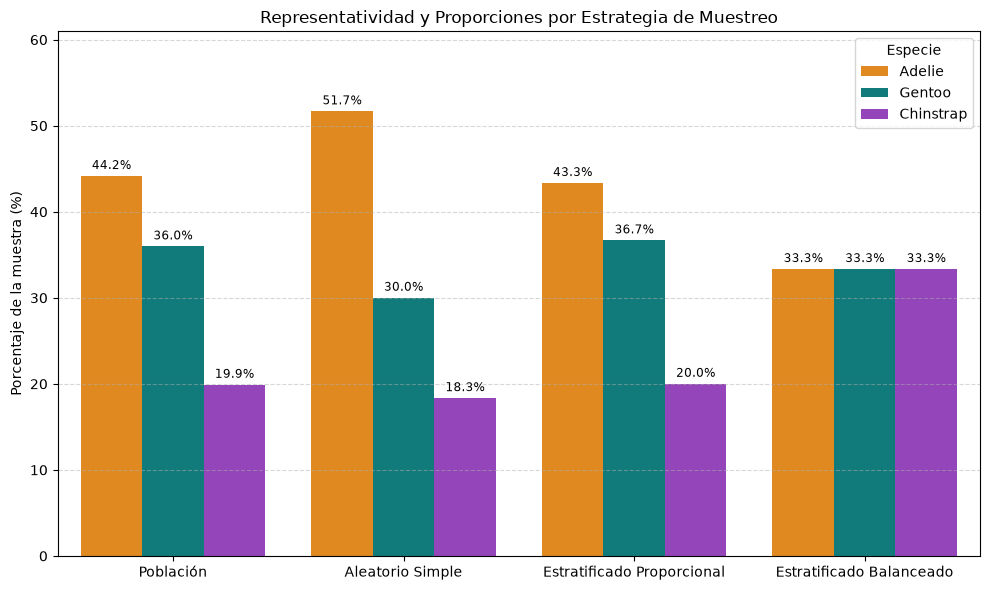

In [30]:
# 1. Muestreo y cálculo de porcentajes
sample_simple = datos_penguins.sample(n=60, random_state=42)

sample_strat_prop, _ = train_test_split(
    datos_penguins, train_size=60, stratify=datos_penguins['species'], random_state=42
)

sample_strat_bal = datos_penguins.groupby('species', group_keys=False).sample(n=20, random_state=42)

muestras = {
    'Población': datos_penguins,
    'Aleatorio Simple': sample_simple,
    'Estratificado Proporcional': sample_strat_prop,
    'Estratificado Balanceado': sample_strat_bal
}

# Tabla de porcentajes (%)
datos_penguins_porcentajes = pd.DataFrame({
    nombre: (s['species'].value_counts(normalize=True) * 100).round(2)
    for nombre, s in muestras.items()
})

print("=== Composición porcentual (%) por especie ===")
print(datos_penguins_porcentajes)
print("\n=== Conteo absoluto de muestras ===")
print(pd.DataFrame({nombre: s['species'].value_counts() for nombre, s in muestras.items()}))

# Conversión a formato largo para graficar
datos_penguins_dist_long = pd.concat([
    s['species'].value_counts(normalize=True).mul(100).rename('Porcentaje').reset_index()
    .rename(columns={'index': 'species'}).assign(Estrategia=nombre)
    for nombre, s in muestras.items()
])

# Visualización con etiquetas de porcentaje sobre cada barra
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=datos_penguins_dist_long, 
    x='Estrategia', 
    y='Porcentaje', 
    hue='species', 
    palette=paleta_penguins
)

# Renderizado de valores en las barras
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f'{h:.1f}%',
            (p.get_x() + p.get_width() / 2., h),
            ha='center', va='bottom',
            fontsize=8.5,
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.title('Representatividad y Proporciones por Estrategia de Muestreo')
plt.ylabel('Porcentaje de la muestra (%)')
plt.xlabel('')
plt.ylim(0, datos_penguins_porcentajes.max().max() * 1.18)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Especie', loc='upper right')
plt.tight_layout()
plt.show()

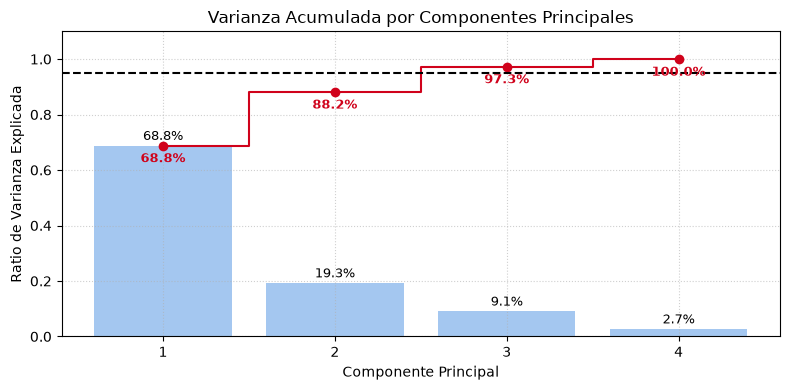

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

# Curva de varianza acumulada
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 5), var_exp, alpha=0.5, color='#4A90E2', label='Varianza individual')
ax.step(range(1, 5), var_cum, where='mid', color='#D0021B', marker='o', label='Varianza acumulada')
ax.axhline(y=0.95, color='black', linestyle='--', label='Umbral 95%')

for i, (v, c) in enumerate(zip(var_exp, var_cum)):
    ax.text(i + 1, v + 0.02, f"{v:.1%}", ha='center', fontsize=9)
    ax.text(i + 1, c - 0.06, f"{c:.1%}", ha='center', fontsize=9, color='#D0021B', weight='bold')

ax.set_xlabel('Componente Principal')
ax.set_ylabel('Ratio de Varianza Explicada')
ax.set_title('Varianza Acumulada por Componentes Principales')
ax.set_xticks(range(1, 5))
ax.set_ylim(0, 1.1)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Con 3 variables, mantenemos el umbral del 95% de la varianza. Intuyo que debido a lo que vimos en el dendograma! Las variables fisicas de la aleta y el peso, estan sumanete relacionadas entre si, por lo que no perdemos varianza al juntarlas (2.7% de la varianza)

reducir una variable en este caso, no tiene mucho sentido,ya que perdemos explicabilidad en las variables, a cambio de reducir una. Si tendria sentido en casos de muchas mas dimensiones, como señales temporales.

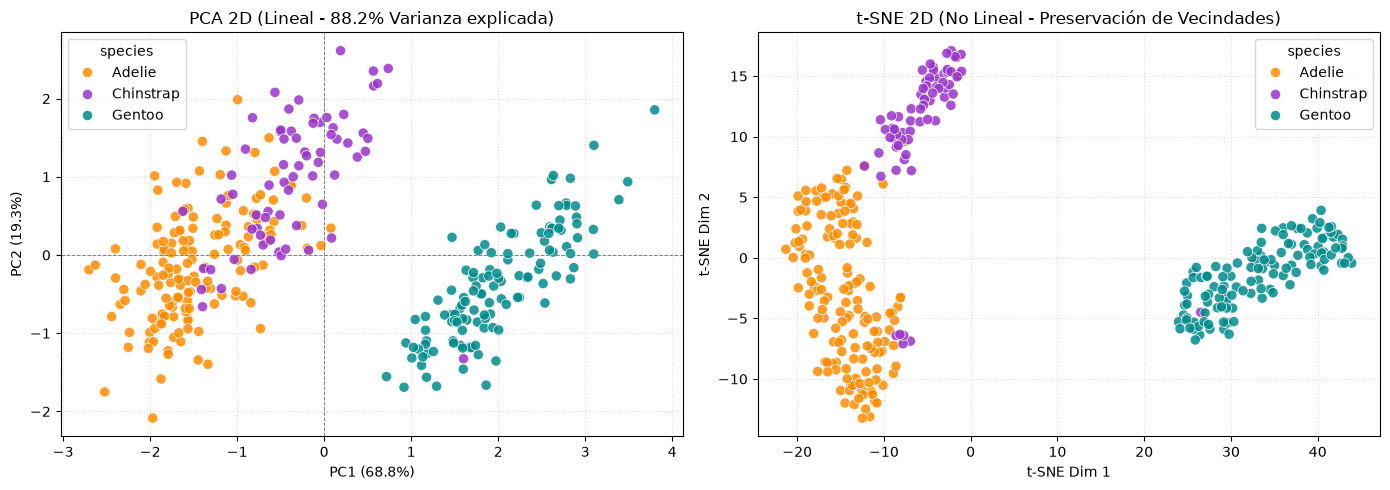

In [32]:
# PCA 2D
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2']).assign(species=y)

# t-SNE 2D
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2']).assign(species=y)

# Gráfico comparativo lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot PCA
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='species',
    palette=paleta_penguins, ax=axes[0], s=55, alpha=0.85
)
axes[0].set_title(f'PCA 2D (Lineal - {var_cum[1]:.1%} Varianza explicada)')
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1%})')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.7)
axes[0].axvline(0, color='grey', linestyle='--', linewidth=0.7)
axes[0].grid(True, linestyle=':', alpha=0.4)

# Plot t-SNE
sns.scatterplot(
    data=df_tsne, x='tSNE1', y='tSNE2', hue='species',
    palette=paleta_penguins, ax=axes[1], s=55, alpha=0.85
)
axes[1].set_title('t-SNE 2D (No Lineal - Preservación de Vecindades)')
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

Vemos que al reducir las componentes a 2 con pca, Gentoo queda completamente separada, pero cuesta un poco mas distinguir Adelie de Chinstrap, quedan bastante superpuestas.

Por otro lado, la tsne permite distinguir Chinstrap con mucha mas facilidad, no hay explicabilidad al respecto, pero debido a la cercania a las distribuciones, permite separarlos bien (algo asi como mirar en el spider plot, y fijarse a cual perfil se parece mas)
